<a href="https://colab.research.google.com/github/srishtiarora42006-hue/Answer/blob/main/Python_Data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
df = pd.read_excel("/content/healthcare_data_cleaning_dataset.xlsx")
print(df)

      Patient_ID   Age  Gender       City     Diagnosis  Hospital_Visits  \
0          17270  35.0    Male  Bangalore  Hypertension               13   
1          10860  21.0  Female  Hyderabad           Flu               11   
2          15390  77.0  Female  Bangalore        Asthma                2   
3          15191  79.0  Female     Mumbai        Asthma               13   
4          15734  60.0  Female      Delhi        Asthma                1   
...          ...   ...     ...        ...           ...              ...   
5095       11764   NaN  Female     Mumbai      COVID-19               15   
5096       17597   NaN  Female    Chennai        Asthma                2   
5097       19171   NaN  Female     Mumbai           Flu                1   
5098       13854   NaN  Female  Bangalore           Flu               17   
5099       14859   NaN    Male      Delhi  Hypertension               19   

      Treatment_Cost  Insurance_Coverage Admission_Date  
0            41010.0         

**Q1.** Missing Data Identification

Scenario:
 The hospital suspects incomplete patient records.

Task:

Identify missing values in each column

Calculate percentage of missing data



In [8]:
# identifying total missing values in each column
df.isnull().sum()

,0
Patient_ID,0
Age,600
Gender,0
City,0
Diagnosis,0
Hospital_Visits,0
Treatment_Cost,593
Insurance_Coverage,0
Admission_Date,0


In [9]:
df.isnull().mean() * 100

,0
Patient_ID,0.000000
Age,11.764706
Gender,0.000000
City,0.000000
Diagnosis,0.000000
Hospital_Visits,0.000000
Treatment_Cost,11.627451
Insurance_Coverage,0.000000
Admission_Date,0.000000


**Q2**. Handling Missing Age

Scenario:
 Age is critical for medical analysis, but some values are missing.

Task:

Replace missing Age values with an appropriate method

Justify your choice (mean/median)

In [10]:
# To replace missing values in the age column we will use MEDIAN imputation bcz of presence of extreme outliers and data skewness.
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Age"]

,Age
0,35.0
1,21.0
2,77.0
3,79.0
4,60.0
...,...
5095,50.0
5096,50.0
5097,50.0
5098,50.0


**Q3.** Handling Missing Treatment Cost

Scenario:
 Treatment cost is highly skewed due to expensive treatments.

Task:

Handle missing Treatment_Cost values

Choose the correct imputation method and explain why

In [11]:
# MEDIAN imputation will be used due to highly skewed data .
df["Treatment_Cost"] = df["Treatment_Cost"].fillna(df["Treatment_Cost"].median())
df["Treatment_Cost"]

,Treatment_Cost
0,41010.0
1,12194.0
2,45086.0
3,40842.0
4,9873.0
...,...
5095,24797.0
5096,24797.0
5097,24797.0
5098,24797.0


**Q4.** Duplicate Patient Records

Scenario:
 Some patient records were entered multiple times.

Task:

Identify duplicate rows

Remove duplicates

Compare dataset size before and after

In [12]:
#identifying duplicate values
df.duplicated().sum()
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
5095,False
5096,True
5097,True
5098,True


In [13]:
#dataset size before removing duplicates
df.shape

(5100, 9)

In [14]:
# removing of duplicates
df = df.drop_duplicates()
print(df)

      Patient_ID   Age  Gender       City     Diagnosis  Hospital_Visits  \
0          17270  35.0    Male  Bangalore  Hypertension               13   
1          10860  21.0  Female  Hyderabad           Flu               11   
2          15390  77.0  Female  Bangalore        Asthma                2   
3          15191  79.0  Female     Mumbai        Asthma               13   
4          15734  60.0  Female      Delhi        Asthma                1   
...          ...   ...     ...        ...           ...              ...   
4996       16135  50.0  Female      Delhi  Hypertension               13   
4997       15573  35.0  Female      Delhi      COVID-19               19   
4998       14131  60.0  Female    Chennai  Hypertension                4   
4999       19900  16.0  Female    Chennai           Flu               16   
5095       11764  50.0  Female     Mumbai      COVID-19               15   

      Treatment_Cost  Insurance_Coverage Admission_Date  
0            41010.0         

In [15]:
#dataset size after removing of duplicates
df.shape
# hence 99 duplicates rows were removed

(5001, 9)

**Q5.** Invalid Age Values (Data Quality Check)

Scenario:
 Some patients have unrealistic age values (e.g., >100 or <0).

Task:

Detect such records

Decide whether to remove or correct them

<Axes: xlabel='Age', ylabel='Count'>

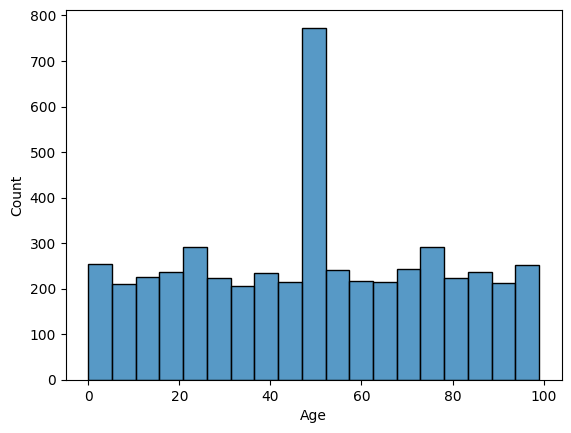

In [16]:
# to detect such records we must import seaborn
import seaborn as sns
sns.histplot(df["Age"])

In [17]:
# detecting the invalid values
df[(df["Age"]>100) | (df["Age"]<0)]

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date


no such records were found which showed age > 100 or <0 hence, no capping or removal process needs to be done.

**Q6.** Outlier Detection (Treatment Cost)

Scenario:
 Extreme treatment costs are affecting analysis.

Task:

Detect outliers using IQR method

Display number of outliers

In [18]:
# calculating Q1 and Q3
Q1 = df["Treatment_Cost"].quantile(0.25)
Q3 = df["Treatment_Cost"].quantile(0.75)
IQR = Q3 - Q1
print(Q1,Q3,IQR)

Upper_bound = Q3 + 1.5 * IQR
Lower_bound = Q1 - 1.5 * IQR
print(Upper_bound,Lower_bound)



13766.0 36542.0 22776.0
70706.0 -20398.0


In [19]:
outliers = df[(df["Treatment_Cost"] > Upper_bound) |
              (df["Treatment_Cost"] < Lower_bound)]

print(outliers)

      Patient_ID   Age  Gender       City     Diagnosis  Hospital_Visits  \
53         13152  91.0  Female    Chennai      COVID-19               13   
86         10064  28.0  Female  Hyderabad  Hypertension               16   
124        17035  59.0    Male      Delhi           Flu                9   
183        15855  36.0    Male     Mumbai      Diabetes                1   
215        19561  29.0    Male     Mumbai           Flu               16   
332        11686  51.0    Male      Delhi        Asthma               16   
382        10876  58.0  Female  Bangalore  Hypertension                1   
416        14070  50.0    Male  Hyderabad           Flu                6   
452        10851  42.0  Female  Bangalore      COVID-19               15   
796        18150  37.0  Female  Bangalore           Flu               17   
833        19361  41.0  Female      Delhi      Diabetes               19   
1127       10943  26.0  Female      Delhi        Asthma               19   
1176       1

**Q7.** Outlier Treatment

Scenario:
The business team wants to retain all records.

Task:

Apply capping (Winsorization) on Treatment_Cost

Use 5th and 95th percentile

In [25]:
import numpy as np
df= df.copy()

df["Treatment_Cost"] = np.where(df["Treatment_Cost"] > Upper_bound,
                                Upper_bound,
                                np.where(df["Treatment_Cost"] < Lower_bound,
                                         Lower_bound,
                                         df["Treatment_Cost"]))
print(df["Treatment_Cost"])

0       41010.0
1       12194.0
2       45086.0
3       40842.0
4        9873.0
         ...   
4996    24797.0
4997     2585.0
4998    31337.0
4999    39801.0
5095    24797.0
Name: Treatment_Cost, Length: 5001, dtype: float64


**Q8.** Transformation

Scenario:
 Treatment cost is highly skewed.

Task:

Apply log transformation

Create a new column

Compare before vs after distribution

In [28]:
df["Log_Treatment_Cost"] = np.log1p(df["Treatment_Cost"])
df["Log_Treatment_Cost"]

,Log_Treatment_Cost
0,10.621596
1,9.408781
2,10.716349
3,10.617491
4,9.197660
...,...
4996,10.118518
4997,7.857868
4998,10.352587
4999,10.591672


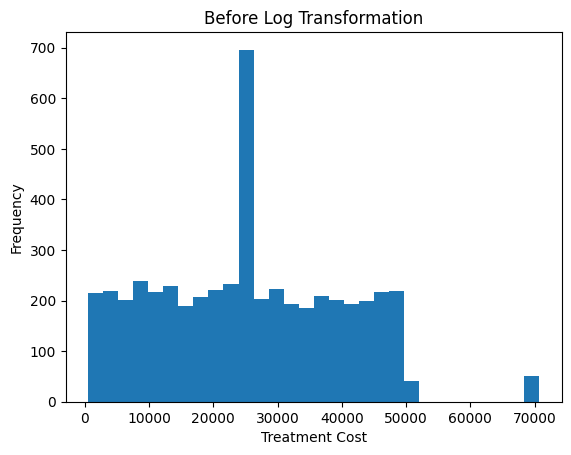

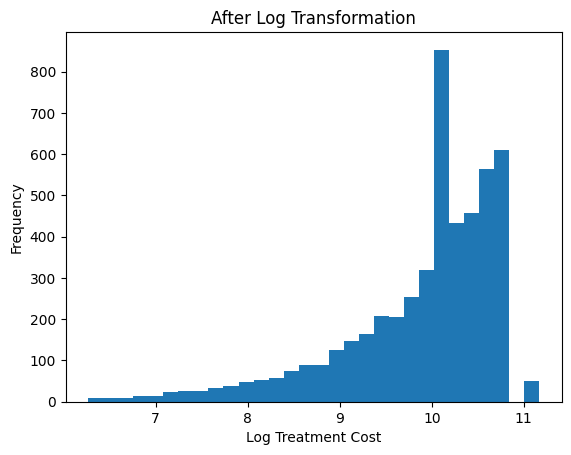

In [34]:
# before vs after transformaion

import matplotlib.pyplot as plt
plt.hist(df["Treatment_Cost"].dropna(),bins = 30)
plt.title("Before Log Transformation")
plt.xlabel("Treatment Cost")
plt.ylabel("Frequency")
plt.show()


plt.hist(df["Log_Treatment_Cost"].dropna(),bins = 30)
plt.title("After Log Transformation")
plt.xlabel("Log Treatment Cost")
plt.ylabel("Frequency")
plt.show()


log transformation was done because the data was highly skewed , it compressed the data , not making it completely a normal distribution but right sknewness was reduced using log transformation.

**Q9.** Time-Based Missing Handling

Scenario:
 Admission dates should follow a logical sequence.

Task:

Sort data by Admission_Date

Apply forward fill or backward fill where appropriate

Justify your choice


In [41]:
# sorting admission dates
df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])
df = df.sort_values(by = "Admission_Date")
df["Admission_Date"]



,Admission_Date
2932,2023-01-01
2838,2023-01-01
4563,2023-01-01
4617,2023-01-01
2642,2023-01-01
...,...
3013,2023-12-31
4744,2023-12-31
3456,2023-12-31
265,2023-12-31


In [43]:
# we will use backward fill here because after sorting admission dates the next value seems more reliable as it continues the sequence hence, backward fill was used here.
df["Admission_Date"]= df["Admission_Date"].bfill()
print(df["Admission_Date"])

2932   2023-01-01
2838   2023-01-01
4563   2023-01-01
4617   2023-01-01
2642   2023-01-01
          ...    
3013   2023-12-31
4744   2023-12-31
3456   2023-12-31
265    2023-12-31
3133   2023-12-31
Name: Admission_Date, Length: 5001, dtype: datetime64[ns]
